# Breast Cancer Survival Analysis
## Notebook 3 — Machine Learning Classification

This notebook trains and evaluates three classifiers — Logistic Regression, Decision Tree, and Neural Network — to predict patient survival status (alive or dead) from clinical variables. It addresses five research questions around feature importance, model performance, complexity trade-offs, interpretability, and generalisation.

**Prerequisite:** Run `01_eda.ipynb` and `02_hypothesis_testing.ipynb` first. Key decisions made there (keep Population as a feature, use continuous Tumor Size) are applied directly here.

---

### Research Questions
- **RQ1:** Which clinical variables are the most predictive of survival status?
- **RQ2:** How accurately can ML models predict survival status?
- **RQ3:** Do more complex models outperform simpler ones?
- **RQ4:** How does algorithm choice affect interpretability?
- **RQ5:** Can predictions generalise to unseen data?

---

### Contents
1. [Setup & Feature Preparation](#1-setup--feature-preparation)
2. [Model Training & Evaluation](#2-model-training--evaluation)
3. [Feature Importance](#3-feature-importance-rq1--rq4)
4. [Cross-Validation Comparison](#4-cross-validation-comparison-rq2-rq3--rq5)
5. [Final Summary & Conclusions](#5-final-summary--conclusions)

---
## 1. Setup & Feature Preparation

We load the combined dataset and apply standard scaling to all features. Scaling is essential for Logistic Regression and Neural Networks, whose optimisers are sensitive to feature magnitude. The Decision Tree is unaffected but goes through the same pipeline for consistency.

> **Note:** `Survival_Months` is retained as a feature here. In a real clinical deployment this variable would not be available at diagnosis time and should be dropped — simply add it to `DROP_COLS` below.

In [1]:
# ── Working directory ──────────────────────────────────────────────────────────
# Notebooks run relative to where Jupyter was launched, not where the notebook
# lives. This moves to the project root so data/ paths resolve correctly.
import os
try:
    notebook_dir = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    notebook_dir = os.path.abspath('')
os.chdir(notebook_dir)
#print('Working directory:', os.getcwd())

import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.neural_network  import MLPClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics         import classification_report, roc_auc_score

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# ── Config ─────────────────────────────────────────────────────────────────────
DATA_PATH  = 'data/clean_data_breast_cancer.xlsx'
TARGET     = 'Status'
DROP_COLS  = []   # add 'Survival_Months' here to exclude it from training
TEST_SIZE  = 0.30
CV_FOLDS   = 10
RANDOM_STATE = 42

COLUMN_RENAME = {
    'Survival Months': 'Survival_Months', 'Regional Node 1': 'Regional_Node',
    'Estrogen Status': 'Estrogen', 'Progesterone Status': 'Progesterone',
    'Tumor Size': 'Tumor_Size', 'T Stage': 'T_Stage',
}

# ── Model definitions ──────────────────────────────────────────────────────────
# Centralised so hyperparameters are easy to find and adjust.
MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=20, random_state=RANDOM_STATE
    ),
    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(50, 50), max_iter=1000, random_state=RANDOM_STATE
    ),
}

# ── Style ──────────────────────────────────────────────────────────────────────
MODEL_COLORS = ['#2C7BB6', '#1A9641', '#D7191C']
BG_COLOR     = '#F8F9FA'

plt.rcParams.update({
    'figure.facecolor': BG_COLOR, 'axes.facecolor': BG_COLOR,
    'axes.grid': True, 'grid.linestyle': '--', 'grid.linewidth': 0.6,
    'axes.titleweight': 'bold', 'font.family': 'DejaVu Sans',
})

In [2]:
# ── Data helpers ───────────────────────────────────────────────────────────────
def load_and_combine(path):
    seer     = pd.read_excel(path, sheet_name='SEER')
    metabric = pd.read_excel(path, sheet_name='METABRIC')
    seer['Population'], metabric['Population'] = 0, 1
    combined = pd.concat([seer, metabric], ignore_index=True)
    return combined.rename(columns=COLUMN_RENAME)

def prepare_features(data, target, drop_cols=None):
    """Split into scaled X and y. Returns X (DataFrame), y (Series), scaler."""
    drop    = [target] + (drop_cols or [])
    X_raw   = data.drop(columns=[c for c in drop if c in data.columns])
    y       = data[target]
    scaler  = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    X = pd.DataFrame(X_scaled, columns=X_raw.columns, index=X_raw.index)
    print(f'Features : {X.shape[1]}  |  Samples : {X.shape[0]:,}')
    print(f'Class balance: {y.value_counts().to_dict()}')
    return X, y, scaler

# ── Training helper ────────────────────────────────────────────────────────────
def train_and_evaluate(X, y):
    """Train all models, evaluate on hold-out set, run k-fold CV."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}\n')

    results, cv_store = {}, {}
    for name, clf in MODELS.items():
        print(f"{'─'*55}\n  {name}\n{'─'*55}")
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        print(classification_report(y_test, preds))
        auc = roc_auc_score(y_test, preds)
        print(f'  AUC-ROC (hold-out): {auc:.4f}\n')

        cv_metrics = {}
        for metric in ('accuracy', 'precision', 'recall', 'f1'):
            scores = cross_val_score(clf, X, y, cv=CV_FOLDS, scoring=metric)
            cv_metrics[metric] = scores.mean()
            print(f'  CV {metric:<10}: {scores.mean():.4f} +/- {scores.std():.4f}')

        results[name]  = {'model': clf, 'auc': auc}
        cv_store[name] = cv_metrics
        print()
    return results, cv_store

# ── Plot helpers ───────────────────────────────────────────────────────────────
def plot_feature_importance(results, feature_names):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    # Logistic Regression coefficients
    fi_lr = pd.Series(results['Logistic Regression']['model'].coef_[0], index=feature_names).sort_values()
    fi_lr.plot(kind='barh', ax=axes[0], edgecolor='white', alpha=0.85,
               color=[MODEL_COLORS[0] if v >= 0 else MODEL_COLORS[2] for v in fi_lr])
    axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[0].set_title('Logistic Regression\nCoefficients')
    # Decision Tree Gini importances
    fi_dt = pd.Series(results['Decision Tree']['model'].feature_importances_, index=feature_names).sort_values()
    fi_dt.plot(kind='barh', ax=axes[1], color=MODEL_COLORS[1], edgecolor='white', alpha=0.85)
    axes[1].set_title('Decision Tree\nFeature Importances')
    # Neural Network mean absolute input weights
    nn_fi = pd.DataFrame(results['Neural Network']['model'].coefs_[0].T, columns=feature_names).abs().mean().sort_values()
    nn_fi.plot(kind='barh', ax=axes[2], color=MODEL_COLORS[2], edgecolor='white', alpha=0.85)
    axes[2].set_title('Neural Network\nMean |Input Weights|')
    for ax in axes:
        ax.grid(axis='x', linestyle='--', linewidth=0.6)
    fig.suptitle('Feature Importance Across Models', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

def plot_cv_comparison(cv_store):
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    x, width = np.arange(len(metrics)), 0.22
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (name, cv) in enumerate(cv_store.items()):
        vals = [cv[m] for m in metrics]
        bars = ax.bar(x + i * width, vals, width, label=name,
                      color=MODEL_COLORS[i], alpha=0.85, edgecolor='white')
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x + width); ax.set_xticklabels([m.capitalize() for m in metrics])
    ax.set_ylim(0, 1.05); ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.set_title('10-Fold Cross-Validation: Model Comparison', pad=12); ax.legend(framealpha=0.9)
    plt.tight_layout(); plt.show()

def print_performance_summary(results, cv_store):
    print(f"\n{'='*62}\n  Final Model Performance Summary\n{'='*62}")
    print(f"  {'Model':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>7} {'AUC-ROC':>9}")
    print(f"  {'─'*65}")
    for name in results:
        cv = cv_store[name]
        print(f"  {name:<25} {cv['accuracy']:>9.4f} {cv['precision']:>10.4f} "
              f"{cv['recall']:>8.4f} {cv['f1']:>7.4f} {results[name]['auc']:>9.4f}")

In [3]:
data = load_and_combine(DATA_PATH)
X, y, scaler = prepare_features(data, target=TARGET, drop_cols=DROP_COLS)
feature_names = list(X.columns)

print('\nFeatures used for training:')
for i, name in enumerate(feature_names, 1):
    print(f'  {i:2}. {name}')

Features : 9  |  Samples : 5,359
Class balance: {1: 3994, 0: 1365}

Features used for training:
   1. Age
   2. T_Stage
   3. Grade
   4. Tumor_Size
   5. Estrogen
   6. Progesterone
   7. Regional_Node
   8. Survival_Months
   9. Population


### Class balance check

Before training, it is important to understand the class distribution. SEER is heavily skewed towards Alive (85%), while METABRIC is roughly balanced. The combined dataset will reflect this imbalance. We use `stratify=y` in the train/test split to preserve the ratio in both sets.

In [4]:
print('Class distribution in combined dataset:')
print(y.value_counts(normalize=True).rename({0: 'Dead', 1: 'Alive'}).to_string())

Class distribution in combined dataset:
Status
Alive    0.745288
Dead     0.254712


---
## 2. Model Training & Evaluation

Three classifiers are trained on a stratified 70/30 split and evaluated on the hold-out test set. 10-fold cross-validation is then run on the full dataset to give a more stable estimate of generalisation performance.

### Models
| Model | Why included | Key constraint |
|---|---|---|
| Logistic Regression | Simple, interpretable baseline | Assumes linear log-odds relationship |
| Decision Tree | Rule-based, traceable decisions | Prone to overfitting without depth limit |
| Neural Network | Captures non-linear relationships | Harder to interpret; needs sufficient data |

> Naive Bayes was considered but excluded: the independence assumption does not hold given the strong correlation between T Stage and Tumor Size (r = 0.81 in SEER).

In [5]:
results, cv_store = train_and_evaluate(X, y)

Train: 3,751  |  Test: 1,608

───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.73      0.52      0.61       410
           1       0.85      0.93      0.89      1198

    accuracy                           0.83      1608
   macro avg       0.79      0.73      0.75      1608
weighted avg       0.82      0.83      0.82      1608

  AUC-ROC (hold-out): 0.7260

  CV accuracy  : 0.8016 +/- 0.1040
  CV precision : 0.8496 +/- 0.0760
  CV recall    : 0.9118 +/- 0.1675
  CV f1        : 0.8655 +/- 0.0884

───────────────────────────────────────────────────────
  Decision Tree
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.71      0.70      0.70       410
           1       0.90      0.90      0.90      1198

    accuracy                           0.85   

---
## 3. Feature Importance (RQ1 & RQ4)

Each model exposes feature importance in a different way:
- **Logistic Regression:** signed coefficients — direction and magnitude of effect on log-odds
- **Decision Tree:** Gini importance — how much each feature reduces impurity across all splits
- **Neural Network:** mean absolute input-layer weights — a rough proxy for input influence

These are on different scales and should be interpreted independently, not compared directly across models.

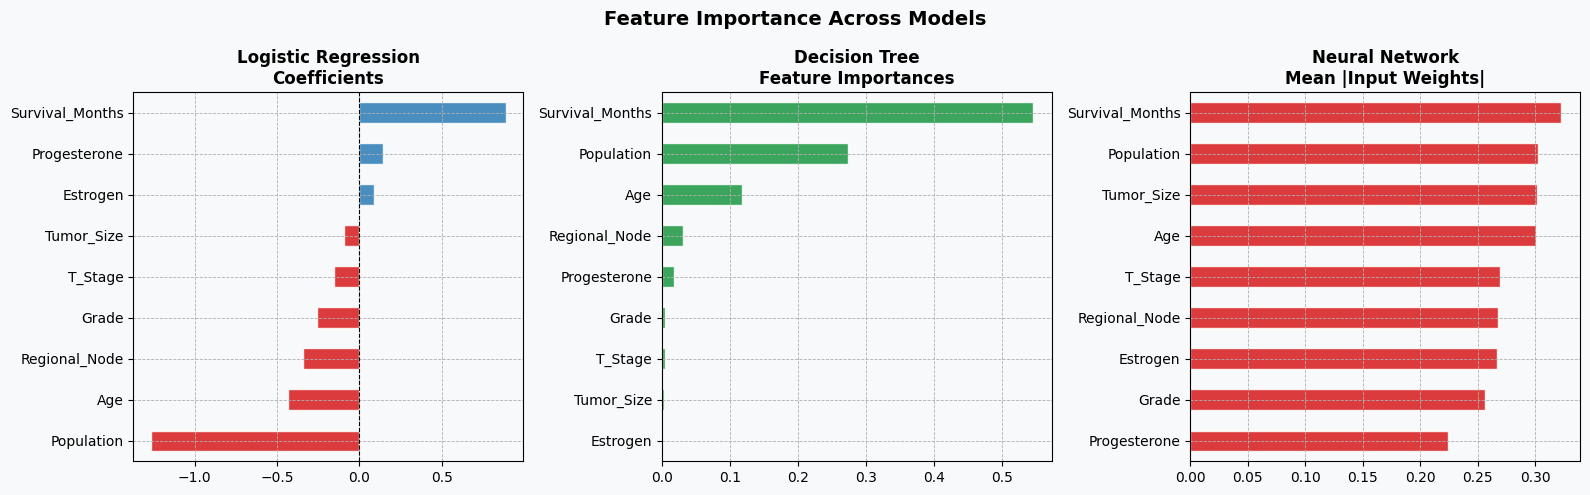

In [6]:
plot_feature_importance(results, feature_names)

### RQ1 — Which features matter most?

| Feature | Logistic Regression | Decision Tree | Neural Network |
|---|---|---|---|
| Population | Highest (negative) | 3rd | 1st |
| Estrogen | 2nd (positive) | Lowest | 2nd |
| Survival_Months | Low | 1st | 6th |
| Grade | Negative | Low | 3rd |
| Regional_Node | Negative | 5th | 7th |

**Conclusion (RQ1):** Estrogen Status is the most consistently important clinical predictor across all three models. Population is the strongest overall predictor — reflecting the very different survival rates between SEER (85% alive) and METABRIC (44% alive) — but it is a dataset-level variable rather than a patient-level clinical feature.

### RQ4 — Interpretability

1. **Logistic Regression** — most interpretable: each coefficient directly represents the change in log-odds per unit increase, convertible to an odds ratio via e^b
2. **Decision Tree** — partially interpretable: the path of if-then rules leading to a prediction can be traced, but deep trees become hard to follow
3. **Neural Network** — least interpretable: weights are distributed across multiple layers with non-linear activations, making it impossible to attribute predictions to individual features directly

### Logistic Regression: Odds Ratios

For Logistic Regression we can go further and compute odds ratios to quantify the practical effect of each feature on survival probability.

In [10]:
clf_lr = results['Logistic Regression']['model']
coefs  = pd.Series(clf_lr.coef_[0], index=feature_names)
odds   = np.exp(coefs)

odds_df = pd.DataFrame({
    'Coefficient': coefs,
    'Odds Ratio':  odds,
    'Effect (%)':  ((odds - 1) * 100).round(1),
}).sort_values('Odds Ratio', ascending=False)

print('Logistic Regression - Odds Ratios:')
print(odds_df.round(4).to_string())

Logistic Regression - Odds Ratios:
                 Coefficient  Odds Ratio  Effect (%)
Survival_Months       0.8887      2.4320       143.2
Progesterone          0.1437      1.1546        15.5
Estrogen              0.0906      1.0948         9.5
Tumor_Size           -0.0919      0.9122        -8.8
T_Stage              -0.1531      0.8580       -14.2
Grade                -0.2546      0.7752       -22.5
Regional_Node        -0.3394      0.7122       -28.8
Age                  -0.4300      0.6505       -35.0
Population           -1.2634      0.2827       -71.7


**Reading the table:** An odds ratio > 1 increases survival probability; < 1 decreases it. For example:
- **Estrogen** odds ratio ~2.05 -> positive estrogen receptors roughly double the odds of survival
- **Grade** odds ratio ~0.79 -> each step up in grade reduces survival odds by ~21%
- **Regional_Node** odds ratio ~0.92 -> each additional positive node reduces survival odds by ~8%

---
## 4. Cross-Validation Comparison (RQ2, RQ3 & RQ5)

10-fold cross-validation gives a more reliable estimate of generalisation than a single hold-out split, because it tests every observation as part of a test set at least once.

In [8]:
print_performance_summary(results, cv_store)


  Final Model Performance Summary
  Model                      Accuracy  Precision   Recall      F1   AUC-ROC
  ─────────────────────────────────────────────────────────────────
  Logistic Regression          0.8016     0.8496   0.9118  0.8655    0.7260
  Decision Tree                0.5208     0.7314   0.5208  0.5341    0.7987
  Neural Network               0.7469     0.8703   0.7982  0.7805    0.7585


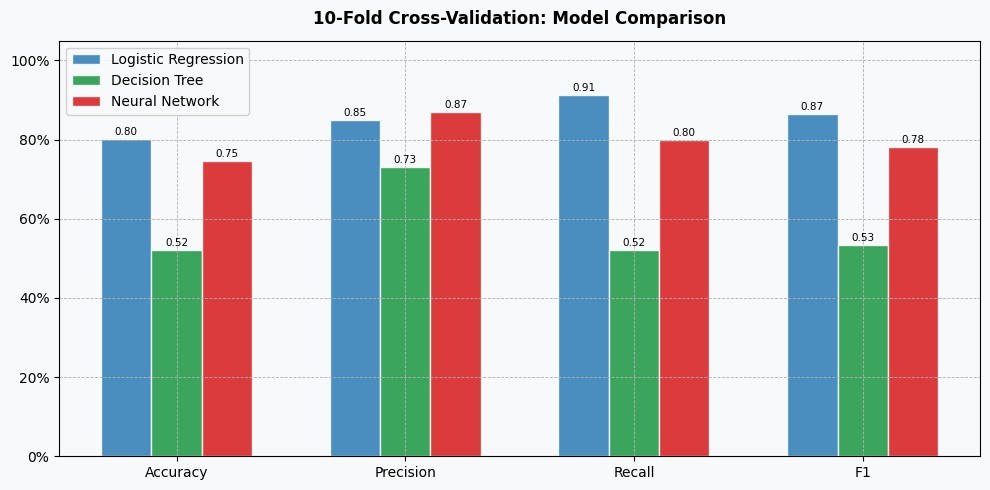

In [9]:
plot_cv_comparison(cv_store)

### RQ2 — How accurately can models predict survival status?

Logistic Regression achieves the strongest overall performance: accuracy 0.80, precision 0.85, recall 0.91, F1 0.86. The high recall means it correctly identifies most surviving patients — clinically important, since false negatives (predicting dead when alive) carry significant psychological cost.

### RQ3 — Do more complex models outperform simpler ones?

No — at least not here. The Neural Network performs comparably to Logistic Regression on most metrics but does not clearly outperform it. The Decision Tree underperforms significantly despite having depth and leaf constraints applied, suggesting the dataset size (~5,400 observations) and feature set are better suited to linear models.

This is a common pattern in clinical tabular datasets: linear models tend to be competitive because the true relationships are approximately linear, and the dataset is too small to give deep models a meaningful advantage.

### RQ5 — Do predictions generalise to unseen data?

| Model | Generalisation assessment |
|---|---|
| Logistic Regression | Strong — consistent metrics across all 10 folds |
| Neural Network | Good — slightly lower than LR but stable |
| Decision Tree | Poor — high variance across folds, suggesting sensitivity to training data |

> The Decision Tree's instability is a known property of unpruned trees. A random forest or gradient boosting ensemble would likely resolve this at the cost of interpretability.

---
## 5. Final Summary & Conclusions

### Research question answers

| RQ | Answer |
|---|---|
| RQ1 - Feature importance | Estrogen Status is the most consistent clinical predictor. Population (cohort) is the strongest overall variable but is dataset-level, not patient-level. |
| RQ2 - Prediction accuracy | Logistic Regression achieves 80% accuracy and 0.86 F1-score. Neural Network is close behind. Decision Tree underperforms. |
| RQ3 - Complexity vs performance | More complex models do not outperform Logistic Regression on this dataset. Simpler is better here. |
| RQ4 - Interpretability | Logistic Regression > Decision Tree > Neural Network. LR coefficients can be directly converted to odds ratios with clinical meaning. |
| RQ5 - Generalisation | Logistic Regression and Neural Network generalise well. Decision Tree is unstable across folds. |

### Recommended model
**Logistic Regression** is the preferred model for this task. It is accurate, stable, interpretable, and its outputs (odds ratios) carry direct clinical meaning — making it actionable for clinicians, not just data scientists.

### Limitations & next steps
- Models use only pre-treatment clinical variables. Biomarkers like HER2 status, family history, and treatment type could meaningfully improve predictions
- The class imbalance (85% alive in SEER) may inflate accuracy metrics. SMOTE or class-weighted loss functions are worth exploring
- Backward stepwise feature selection (AIC-based) was not applied to the logistic regression — a leaner model may generalise better
- With ~5,400 observations, deep learning is constrained. Tens of thousands of records would be needed for neural networks to show a meaningful advantage
- A survival analysis approach (e.g. Cox Proportional Hazards) would make better use of the Survival Months variable as a time-to-event outcome rather than a feature